pip install opencv-python

In [1]:
import cv2

print(cv2.__version__)

4.13.0


In [2]:
import numpy as np
height = 480
width = 640
color = np.zeros((height, width, 3), dtype=np.uint8)  # Create a black image of size 640x480 with 3 channels (BGR) and 8-bit unsigned integers  

In [3]:
gray = np.zeros((height, width), dtype=np.uint8)  # Create a black image of size 640x480 with 1 channel (grayscale) and 8-bit unsigned integers

In [5]:
print(f"Color Image Size: {color.shape}")
print(f"Gray Image Size: {gray.shape}")

Color Image Size: (480, 640, 3)
Gray Image Size: (480, 640)


## 히스토그램


In [10]:
import cv2
import numpy as np

# cv2.imread: 파일 경로에서 이미지를 BGR 형식으로 읽어옵니다.
image = cv2.imread("../../opencv4/Chapter2/Example-02-08-Py/image.jpg")

# cv2.cvtColor: 컬러(BGR) 이미지를 그레이스케일(단일 채널)로 변환합니다.
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# np.zeros: 히스토그램 그래프를 그릴 빈 캔버스(높이=image 높이, 너비=256)를 생성합니다.
result = np.zeros((image.shape[0], 256), dtype=np.uint8)

# cv2.calcHist: 지정 채널(여기서는 0번 채널)의 256-bin 히스토그램을 계산합니다.
#“이미지 전체에서 Blue 채널 값을 0~255 범위로 256칸으로 나눠 빈도를 계산”하는 호출입니다.
hist = cv2.calcHist([image], [0], None, [256], [0, 256])

# cv2.normalize: 히스토그램 값을 0~255 범위로 정규화해 화면에 그리기 쉽게 만듭니다.
cv2.normalize(hist, hist, 0, 255, cv2.NORM_MINMAX)

# enumerate + hist.ravel(): (256,1) 히스토그램을 1차원으로 펴고 인덱스(x), 값(y)으로 순회합니다.
for x, y in enumerate(hist.ravel()):
    # cv2.line: 각 x 위치에 세로 막대를 그려 히스토그램 형태를 만듭니다.
    cv2.line(result, (x, image.shape[0] - 1), (x, image.shape[0] - 1 - int(y)), 255)

# np.hstack: 원본 채널 이미지와 히스토그램 이미지를 가로로 이어 붙입니다.
dst = np.hstack([image[:, :, 0], result])

# cv2.imshow: 별도 창으로 결과 이미지를 표시합니다 (노트북 환경에서는 제한될 수 있음).
cv2.imshow("dst", dst)

# cv2.waitKey(0): 키 입력이 들어올 때까지 창을 유지합니다.
cv2.waitKey(0)

# cv2.destroyAllWindows: OpenCV로 띄운 모든 창을 닫습니다.
cv2.destroyAllWindows()

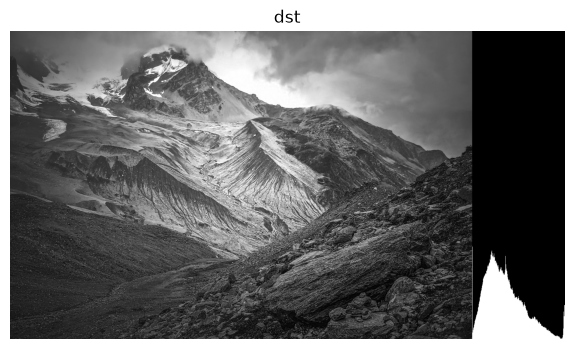

In [11]:
import matplotlib.pyplot as plt

# dst가 단일 채널(그레이)이면
plt.figure(figsize=(10, 4))
plt.imshow(dst, cmap="gray")
plt.title("dst")
plt.axis("off")
plt.show()